# Two Univariate Gaussians: LDA from Scratch

This notebook rebuilds a full binary LDA example for one-dimensional data **without** using `LDAHead`.

We will:
1. Generate two Gaussian classes in 1D.
2. Fit LDA by closed-form MLE.
3. Fit the same LDA parameters with PyTorch SGD.
4. Add an end-to-end **one-hidden-layer NN + LDA** model.
5. Compare test accuracy, posterior curves, and decision boundaries.


In [1]:
import math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

np.random.seed(7)
torch.manual_seed(7)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
print("torch", torch.__version__)


torch 2.9.1+cu130


In [2]:
# Synthetic binary data: x | y=0 ~ N(mu0, var), x | y=1 ~ N(mu1, var)
mu0_true, mu1_true = -2.0, 2.0
var_true = 1.0
p1_true = 0.5

n_train = 700
n_test = 300


def sample_split(n):
    y = (np.random.rand(n) < p1_true).astype(np.int64)
    means = np.where(y == 0, mu0_true, mu1_true)
    x = means + np.sqrt(var_true) * np.random.randn(n)
    return x.astype(np.float32), y


x_train_np, y_train_np = sample_split(n_train)
x_test_np, y_test_np = sample_split(n_test)

x_train = torch.from_numpy(x_train_np)
y_train = torch.from_numpy(y_train_np)
x_test = torch.from_numpy(x_test_np)
y_test = torch.from_numpy(y_test_np)

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)
print("Class balance train (p(y=1)):", y_train.float().mean().item())


Train shape: torch.Size([700]) torch.Size([700])
Test shape: torch.Size([300]) torch.Size([300])
Class balance train (p(y=1)): 0.5185714364051819


In [3]:
# Closed-form LDA fit (shared univariate variance)
def lda_log_posteriors_1d(x, mu, var, log_priors):
    # x: (N,), mu: (2,), scalar var, log_priors: (2,)
    diff2 = (x[:, None] - mu[None, :]) ** 2
    log_lik = -0.5 * (math.log(2.0 * math.pi) + torch.log(var) + diff2 / var)
    return log_lik + log_priors[None, :]


x0 = x_train[y_train == 0]
x1 = x_train[y_train == 1]

mu_cf = torch.stack([x0.mean(), x1.mean()])
var_cf = (((x0 - mu_cf[0]) ** 2).sum() + ((x1 - mu_cf[1]) ** 2).sum()) / x_train.numel()
priors_cf = torch.tensor([(y_train == 0).float().mean(), (y_train == 1).float().mean()])
log_priors_cf = torch.log(priors_cf)

with torch.no_grad():
    logp_test_cf = lda_log_posteriors_1d(x_test, mu_cf, var_cf, log_priors_cf)
    pred_test_cf = logp_test_cf.argmax(dim=1)
    acc_cf = (pred_test_cf == y_test).float().mean().item()

print("Closed-form estimates")
print("mu:", mu_cf.tolist())
print("var:", var_cf.item())
print("priors:", priors_cf.tolist())
print("Test accuracy:", round(acc_cf, 4))


Closed-form estimates
mu: [-2.0350470542907715, 2.045894145965576]
var: 0.9201520681381226
priors: [0.4814285635948181, 0.5185714364051819]
Test accuracy: 0.9567


In [4]:
# SGD fit of the same LDA model parameters (still from scratch, no custom nn.Module)
mu_sgd = torch.nn.Parameter(torch.tensor([-0.2, 0.2], dtype=torch.float32))
log_var_sgd = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float32))
prior_logits_sgd = torch.nn.Parameter(torch.zeros(2, dtype=torch.float32))

optimizer = torch.optim.Adam([mu_sgd, log_var_sgd, prior_logits_sgd], lr=0.05)
loss_trace = []

for step in range(1500):
    optimizer.zero_grad()

    var_sgd = F.softplus(log_var_sgd) + 1e-6
    log_priors_sgd = F.log_softmax(prior_logits_sgd, dim=0)

    logp_train = lda_log_posteriors_1d(x_train, mu_sgd, var_sgd, log_priors_sgd)
    loss = F.nll_loss(logp_train, y_train)
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        loss_trace.append((step, loss.item()))

with torch.no_grad():
    var_sgd = F.softplus(log_var_sgd) + 1e-6
    priors_sgd = F.softmax(prior_logits_sgd, dim=0)
    logp_test_sgd = lda_log_posteriors_1d(x_test, mu_sgd, var_sgd, torch.log(priors_sgd))
    pred_test_sgd = logp_test_sgd.argmax(dim=1)
    acc_sgd = (pred_test_sgd == y_test).float().mean().item()

print("SGD estimates")
print("mu:", mu_sgd.detach().tolist())
print("var:", var_sgd.item())
print("priors:", priors_sgd.detach().tolist())
print("Test accuracy:", round(acc_sgd, 4))


SGD estimates
mu: [-2.0350468158721924, 2.045893907546997]
var: 0.9201520085334778
priors: [0.4814285337924957, 0.5185715556144714]
Test accuracy: 0.9567


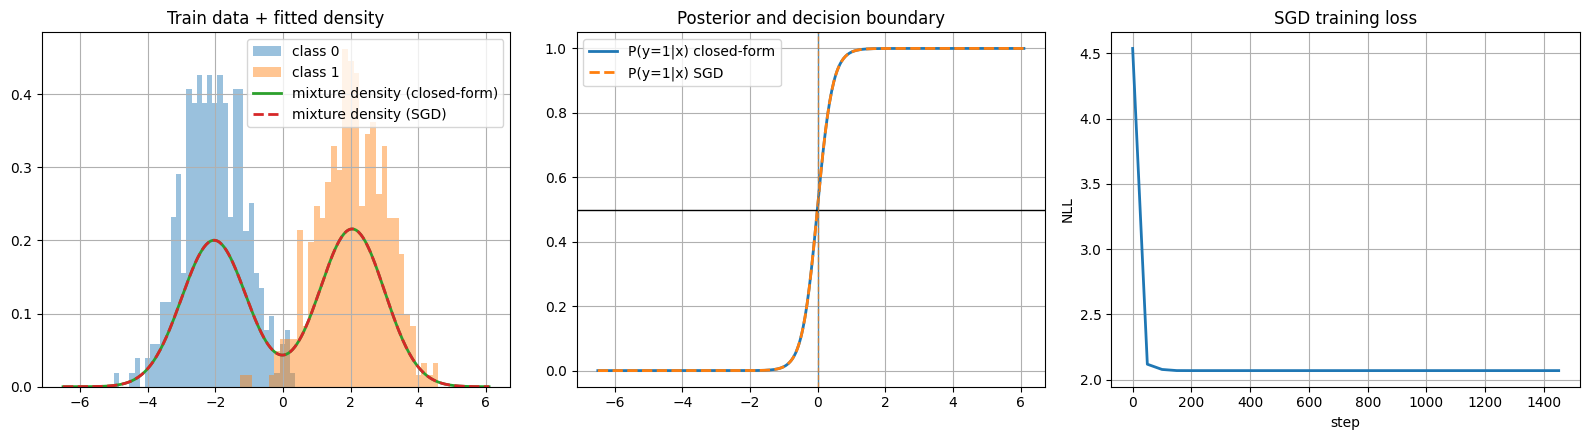

Closed-form boundary ~ 0.002
SGD boundary ~ 0.002


In [5]:
# Visual comparison: data histogram, fitted densities, posterior P(y=1|x), and training loss
x_grid = torch.linspace(x_train.min() - 1.5, x_train.max() + 1.5, 400)


def normal_pdf(x, mu, var):
    return torch.exp(-0.5 * (x - mu) ** 2 / var) / torch.sqrt(2.0 * math.pi * var)

with torch.no_grad():
    p0_cf, p1_cf = priors_cf
    dens_cf = p0_cf * normal_pdf(x_grid, mu_cf[0], var_cf) + p1_cf * normal_pdf(x_grid, mu_cf[1], var_cf)

    p0_sgd, p1_sgd = priors_sgd
    dens_sgd = p0_sgd * normal_pdf(x_grid, mu_sgd[0], var_sgd) + p1_sgd * normal_pdf(x_grid, mu_sgd[1], var_sgd)

    post_cf = torch.softmax(lda_log_posteriors_1d(x_grid, mu_cf, var_cf, torch.log(priors_cf)), dim=1)[:, 1]
    post_sgd = torch.softmax(lda_log_posteriors_1d(x_grid, mu_sgd, var_sgd, torch.log(priors_sgd)), dim=1)[:, 1]

    boundary_cf = x_grid[torch.argmin(torch.abs(post_cf - 0.5))].item()
    boundary_sgd = x_grid[torch.argmin(torch.abs(post_sgd - 0.5))].item()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(x_train_np[y_train_np == 0], bins=35, density=True, alpha=0.45, label="class 0")
axes[0].hist(x_train_np[y_train_np == 1], bins=35, density=True, alpha=0.45, label="class 1")
axes[0].plot(x_grid.numpy(), dens_cf.numpy(), lw=2, label="mixture density (closed-form)")
axes[0].plot(x_grid.numpy(), dens_sgd.detach().numpy(), lw=2, ls="--", label="mixture density (SGD)")
axes[0].set_title("Train data + fitted density")
axes[0].legend()

axes[1].plot(x_grid.numpy(), post_cf.numpy(), lw=2, label="P(y=1|x) closed-form")
axes[1].plot(x_grid.numpy(), post_sgd.detach().numpy(), lw=2, ls="--", label="P(y=1|x) SGD")
axes[1].axhline(0.5, color="black", lw=1)
axes[1].axvline(boundary_cf, color="C0", lw=1, alpha=0.7)
axes[1].axvline(boundary_sgd, color="C1", lw=1, alpha=0.7, ls="--")
axes[1].set_title("Posterior and decision boundary")
axes[1].legend()

steps, losses = zip(*loss_trace)
axes[2].plot(steps, losses, lw=2)
axes[2].set_title("SGD training loss")
axes[2].set_xlabel("step")
axes[2].set_ylabel("NLL")

plt.tight_layout()
plt.show()

print(f"Closed-form boundary ~ {boundary_cf:.3f}")
print(f"SGD boundary ~ {boundary_sgd:.3f}")


## NN + LDA (One-Hidden-Layer)

Here we learn a feature map `phi(x)` with a one-hidden-layer MLP, then apply LDA in feature space with trainable class means, shared variance, and class priors.


In [6]:
# One-hidden-layer NN feature map + LDA in feature space
class OneHiddenFeatureNet(torch.nn.Module):
    def __init__(self, hidden_dim=2, feat_dim=1):
        super().__init__()
        self.fc1 = torch.nn.Linear(1, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, feat_dim)

    def forward(self, x):
        # x: (N,) -> (N, 1)
        h = torch.tanh(self.fc1(x.unsqueeze(1)))
        z = self.fc2(h)
        return z


def lda_log_posteriors_feat(z, mu, var, log_priors):
    # z: (N, D), mu: (2, D), scalar var
    diff2 = ((z[:, None, :] - mu[None, :, :]) ** 2).sum(dim=-1)
    D = z.shape[1]
    log_lik = -0.5 * (D * torch.log(2.0 * torch.pi * var) + diff2 / var)
    return log_lik + log_priors[None, :]


feat_net = OneHiddenFeatureNet(hidden_dim=2, feat_dim=1)
mu_nn = torch.nn.Parameter(torch.zeros(2, 1))
log_var_nn = torch.nn.Parameter(torch.tensor(0.0))
prior_logits_nn = torch.nn.Parameter(torch.zeros(2))

optimizer_nn = torch.optim.Adam(
    list(feat_net.parameters()) + [mu_nn, log_var_nn, prior_logits_nn],
    lr=0.01,
)

loss_trace_nn = []
for step in range(3000):
    optimizer_nn.zero_grad()

    z_train = feat_net(x_train)
    var_nn = F.softplus(log_var_nn) + 1e-6
    log_priors_nn = F.log_softmax(prior_logits_nn, dim=0)
    logp_train_nn = lda_log_posteriors_feat(z_train, mu_nn, var_nn, log_priors_nn)

    loss_nn = F.nll_loss(logp_train_nn, y_train)
    loss_nn.backward()
    optimizer_nn.step()

    if step % 100 == 0:
        loss_trace_nn.append((step, loss_nn.item()))

with torch.no_grad():
    z_test = feat_net(x_test)
    var_nn = F.softplus(log_var_nn) + 1e-6
    priors_nn = F.softmax(prior_logits_nn, dim=0)
    logp_test_nn = lda_log_posteriors_feat(z_test, mu_nn, var_nn, torch.log(priors_nn))
    pred_test_nn = logp_test_nn.argmax(dim=1)
    acc_nn = (pred_test_nn == y_test).float().mean().item()

print("NN+LDA estimates")
print("mu (feature space):")
print(mu_nn.detach())
print("shared var:", var_nn.item())
print("priors:", priors_nn.detach().tolist())
print("Test accuracy:", round(acc_nn, 4))


NN+LDA estimates
mu (feature space):
tensor([[-0.2068],
        [-0.2068]])
shared var: 1.1495044418552425e-06
priors: [0.4814285635948181, 0.5185714364051819]
Test accuracy: 0.4967


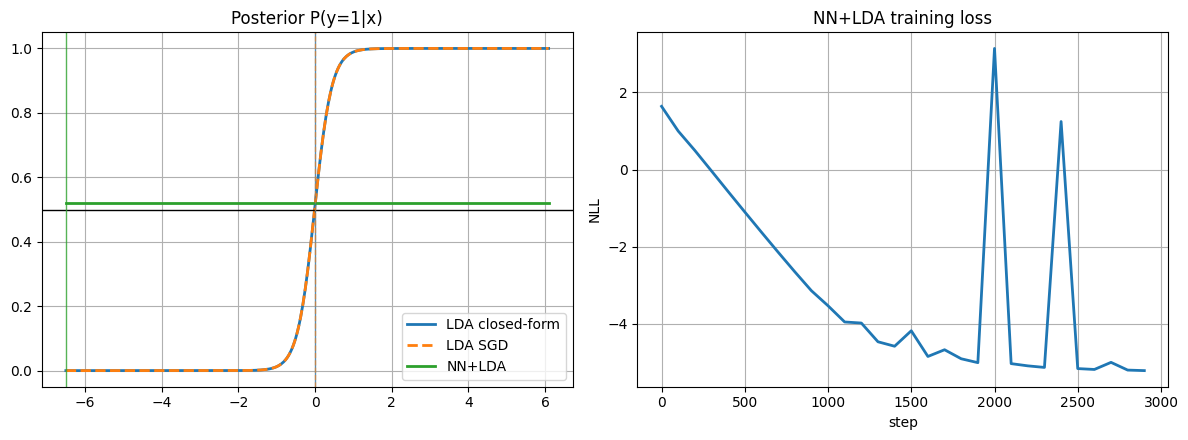

NN+LDA boundary ~ -6.500


In [7]:
# NN+LDA posterior in input space + NN training loss
x_grid_nn = torch.linspace(x_train.min() - 1.5, x_train.max() + 1.5, 500)

with torch.no_grad():
    z_grid_nn = feat_net(x_grid_nn)
    post_nn = torch.softmax(
        lda_log_posteriors_feat(z_grid_nn, mu_nn, var_nn, torch.log(priors_nn)),
        dim=1,
    )[:, 1]

    boundary_nn = x_grid_nn[torch.argmin(torch.abs(post_nn - 0.5))].item()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(x_grid.numpy(), post_cf.numpy(), lw=2, label="LDA closed-form")
axes[0].plot(x_grid.numpy(), post_sgd.detach().numpy(), lw=2, ls="--", label="LDA SGD")
axes[0].plot(x_grid_nn.numpy(), post_nn.detach().numpy(), lw=2, label="NN+LDA")
axes[0].axhline(0.5, color="black", lw=1)
axes[0].axvline(boundary_cf, color="C0", lw=1, alpha=0.6)
axes[0].axvline(boundary_sgd, color="C1", lw=1, alpha=0.6, ls="--")
axes[0].axvline(boundary_nn, color="C2", lw=1, alpha=0.8)
axes[0].set_title("Posterior P(y=1|x)")
axes[0].legend()

steps_nn, losses_nn = zip(*loss_trace_nn)
axes[1].plot(steps_nn, losses_nn, lw=2)
axes[1].set_title("NN+LDA training loss")
axes[1].set_xlabel("step")
axes[1].set_ylabel("NLL")

plt.tight_layout()
plt.show()

print(f"NN+LDA boundary ~ {boundary_nn:.3f}")


In [8]:
print("Summary")
print(f"Closed-form LDA test accuracy: {acc_cf:.4f}")
print(f"SGD LDA test accuracy:         {acc_sgd:.4f}")
print(f"One-hidden-layer NN+LDA acc:   {acc_nn:.4f}")


Summary
Closed-form LDA test accuracy: 0.9567
SGD LDA test accuracy:         0.9567
One-hidden-layer NN+LDA acc:   0.4967
